<a href="https://colab.research.google.com/github/A01801224/TC3009C-RI/blob/main/Reto_Primer_Avance_Spaceship_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto: Primer Avance
## Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

# 1. CARGA Y COMPRENSIÓN DEL DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pega aquí el enlace Raw de tu archivo
url_test = "https://raw.githubusercontent.com/A01801224/TC3009C-RI/refs/heads/main/test.csv"
url_train = "https://raw.githubusercontent.com/A01801224/TC3009C-RI/refs/heads/main/train.csv"

# Pandas lee el archivo directamente desde GitHub
df_test = pd.read_csv(url_test)
df_train = pd.read_csv(url_train)


**Nota sobre `test.csv`:** se carga únicamente como referencia para conservar la misma estructura de variables. En este primer avance, todo el EDA, la selección de variables y las decisiones de preprocesamiento se realizan exclusivamente con `train.csv`, ya que contiene la variable objetivo `Transported`. Una vez definido el pipeline final, las mismas transformaciones podrán aplicarse a `test.csv`.


In [ ]:
print(df_train.shape)
df_train.describe()
print("Target:", df_train["Transported"].dtype, df_train["Transported"].unique())

(8693, 14)
Target: bool [False  True]


Dado que Transported devuelve un valor booleano, estamos hablando de un problema de clasificación, debemos ser capaces de predecir False o True

# 2. EDA

In [ ]:
#Revisión de train

df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [ ]:
#Calculo de mean para que las columnas con valores binarios
(df_train.isnull().mean()*100).round(4).sort_values(ascending=False)

,0
CryoSleep,2.4963
ShoppingMall,2.3927
VIP,2.3352
HomePlanet,2.3122
Name,2.3007
Cabin,2.2892
VRDeck,2.1627
Spa,2.1051
FoodCourt,2.1051
Destination,2.0936


Al hacer el calculo de porcentaje de valores nulos por columna, observamos que casi todas las variables (a excepción ed PassengerId y Transported) presentan un porcentaje de datos faltante muy similar, entre 2.05% y 2.50%. No hay ninguna columna que destaque por encima de las demás

## Primer Acercamineto, Analisis y Clasificación de Variables

In [ ]:
df_train.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


Este primer acercamineto, analisis y clasificación de variables esta sujeto a cambios

**Categóricas** (baja cardinalidad, útiles para value_counts/groupby directo):
- HomePlanet
- CryoSleep
- Destination
- VIP
- Transported (variable objetivo)

**Numéricas continuas** (tiene sentido calcular media, mediana, dispersión):
- Age
- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck

**Identificadores ** (no son categóricas ni numéricas puras tal como están):
- PassengerId → posible extracción de número de grupo
- Cabin → posible división en Deck, Number, Side
- Name → no aporta directamente al análisis en su forma actual

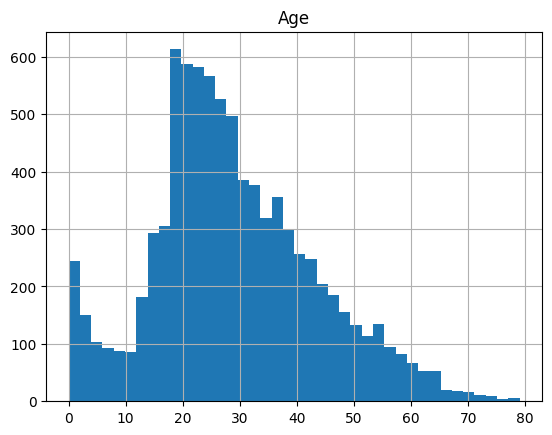

Age skew: 0.41909658301471536
Age outliers Tukey: 77


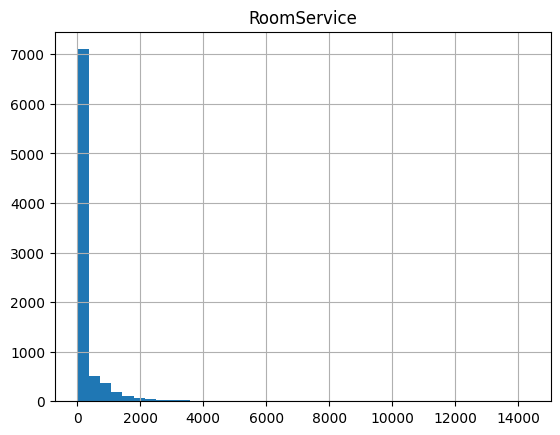

RoomService skew: 6.333014062092135
RoomService outliers Tukey: 1861


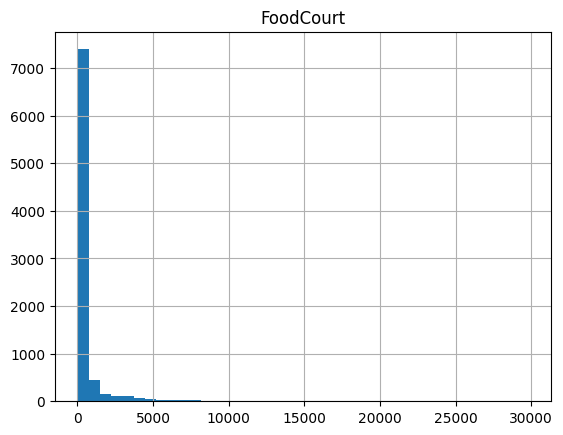

FoodCourt skew: 7.102227852514122
FoodCourt outliers Tukey: 1823


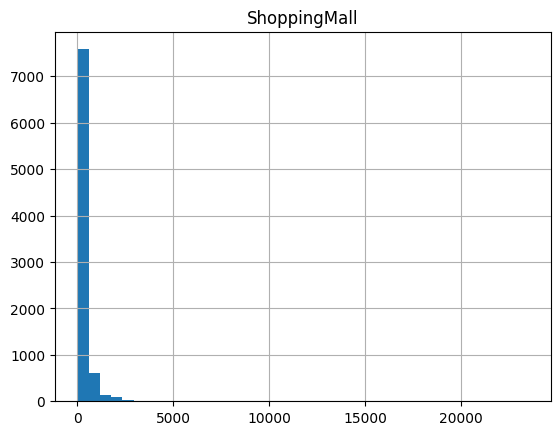

ShoppingMall skew: 12.62756203889759
ShoppingMall outliers Tukey: 1829


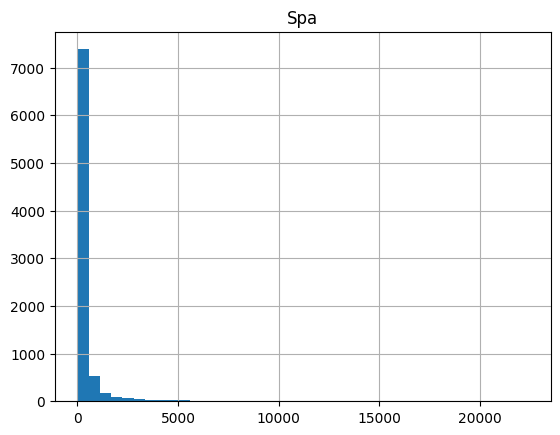

Spa skew: 7.63601988471242
Spa outliers Tukey: 1788


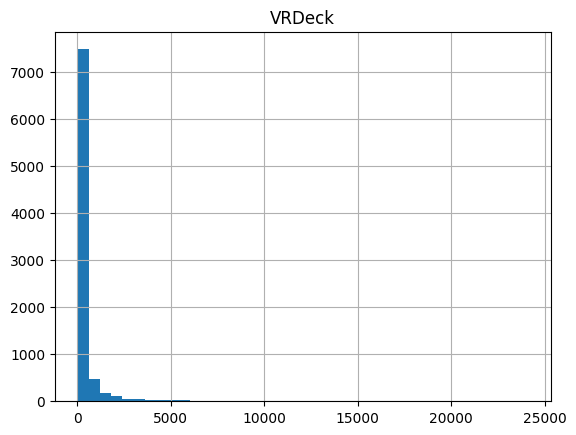

VRDeck skew: 7.819731592048683
VRDeck outliers Tukey: 1809


In [ ]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
import matplotlib.pyplot as plt
num_cols = ["Age"] + spend_cols
for col in num_cols:
    df_train[col].hist(bins=40)
    plt.title(col)
    plt.show()
    print(col, "skew:", df_train[col].skew())
    q1, q3 = df_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df_train[(df_train[col] < lower) | (df_train[col] > upper)]
    print(col, "outliers Tukey:", outliers.shape[0])

Al analizar la distribución de las variables numéricas encontramos dos comportamientos muy distintos. Age tiene un skewness de 0.42, lo que indica una distribución prácticamente simétrica, sin necesidad de transformación.

En cambio, las cinco variables de gasto (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) presentan skewness muy alto (entre 6.3 y 12.6), con aproximadamente 1,800 valores marcados como outliers por la regla de Tukey en cada una (~21% de los registros)

In [ ]:
# Evaluación de binarización para variables con concentración extrema en cero

spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in spend_cols:
    flag = f"Has_{col}"

    df_train[flag] = np.where(
        df_train[col].isna(),
        np.nan,
        (df_train[col] > 0).astype(int)
    )

    print(f"\n--- {col} ---")

    print(
        "Porcentaje de ceros:",
        round((df_train[col].fillna(0) == 0).mean() * 100, 2),
        "%"
    )

    print("Tasa de Transported según 0 vs >0:")

    print(
        pd.crosstab(
            df_train[flag],
            df_train["Transported"],
            normalize="index"
        )
    )


--- RoomService ---
Porcentaje de ceros: 66.24 %
Tasa de Transported según 0 vs >0:
Transported         False     True 
Has_RoomService                    
0.0              0.366685  0.633315
1.0              0.740034  0.259966

--- FoodCourt ---
Porcentaje de ceros: 64.87 %
Tasa de Transported según 0 vs >0:
Transported       False     True 
Has_FoodCourt                    
0.0            0.409091  0.590909
1.0            0.654551  0.345449

--- ShoppingMall ---
Porcentaje de ceros: 66.66 %
Tasa de Transported según 0 vs >0:
Transported          False     True 
Has_ShoppingMall                    
0.0               0.401289  0.598711
1.0               0.682885  0.317115

--- Spa ---
Porcentaje de ceros: 63.35 %
Tasa de Transported según 0 vs >0:
Transported     False     True 
Has_Spa                        
0.0          0.360819  0.639181
1.0          0.722536  0.277464

--- VRDeck ---
Porcentaje de ceros: 65.37 %
Tasa de Transported según 0 vs >0:
Transported     False     True 
H

In [ ]:
# Variable binaria global: indica si el pasajero gastó
# en al menos uno de los servicios de la nave

gasto_total_observado = df_train[spend_cols].sum(axis=1, min_count=1)

df_train["HasSpent"] = np.where(
    gasto_total_observado.isna(),
    np.nan,
    (gasto_total_observado > 0).astype(int)
)

print(pd.crosstab(
    df_train["HasSpent"],
    df_train["Transported"],
    normalize="index"
))

Transported     False     True 
HasSpent                       
0.0          0.213523  0.786477
1.0          0.701389  0.298611


### Evaluación de binarización de las variables de gasto

Las variables de gasto presentan una concentración muy alta en cero, por lo que se evaluó explícitamente si una representación binaria, es decir, distinguir entre pasajeros que no gastaron y pasajeros que sí realizaron algún gasto, conserva información relacionada con `Transported`.

La comparación muestra que el patrón de gasto cero frente a gasto positivo aporta información útil. Sin embargo, las variables continuas se mantienen porque también contienen información sobre la magnitud del consumo. Posteriormente se aplicará una transformación `log1p` para reducir su fuerte sesgo positivo.

Además, se conserva la variable global `HasSpent`, que resume si el pasajero realizó al menos un gasto. Las banderas individuales se utilizan principalmente como evidencia durante el EDA para evitar agregar demasiadas variables redundantes.


In [ ]:
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
for col in cat_cols:
    print(col, df_train[col].value_counts(normalize=True, dropna=False)*100)

HomePlanet HomePlanet
Earth     52.939146
Europa    24.513977
Mars      20.234672
NaN        2.312205
Name: proportion, dtype: float64
CryoSleep CryoSleep
False    62.567583
True     34.936156
NaN       2.496261
Name: proportion, dtype: float64
Destination Destination
TRAPPIST-1e      68.043253
55 Cancri e      20.706315
PSO J318.5-22     9.156793
NaN               2.093639
Name: proportion, dtype: float64
VIP VIP
False    95.375590
NaN       2.335212
True      2.289198
Name: proportion, dtype: float64


Al revisar la cardinalidad y distribución de las variables categóricas encontramos niveles de desbalance muy distintos entre ellas. HomePlanet y Destination tienen una distribución razonablemente repartida entre sus categorías (Earth 53%/Europa 25%/Mars 20%, y TRAPPIST-1e 68%/55 Cancri e 21%/PSO J318.5-22 9%, respectivamente).

CryoSleep está más balanceada (63% False / 35% True). En cambio, VIP presenta un desbalance muy grande: 95.4% de los pasajeros no son VIP y solo 2.3% sí lo son, con un 2.3% adicional de nulos

Transported     False     True 
HomePlanet                     
Earth        0.576054  0.423946
Europa       0.341154  0.658846
Mars         0.476976  0.523024
Transported     False     True 
CryoSleep                      
False        0.671079  0.328921
True         0.182417  0.817583
Transported       False     True 
Destination                      
55 Cancri e    0.390000  0.610000
PSO J318.5-22  0.496231  0.503769
TRAPPIST-1e    0.528825  0.471175
Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910


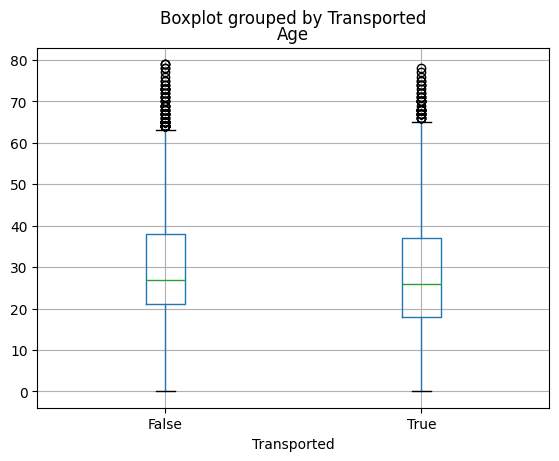

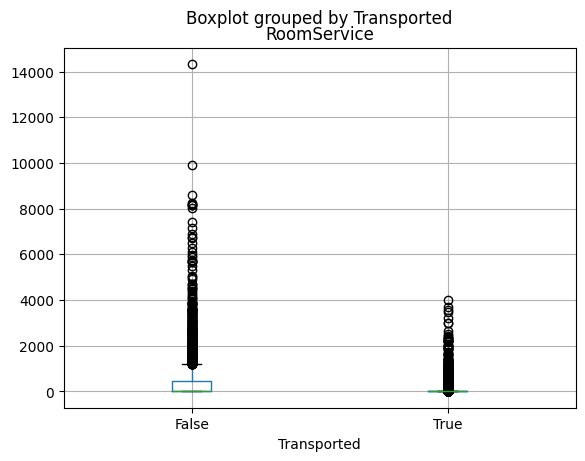

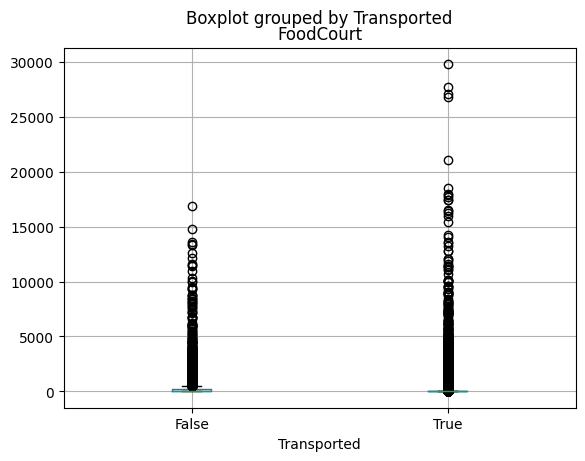

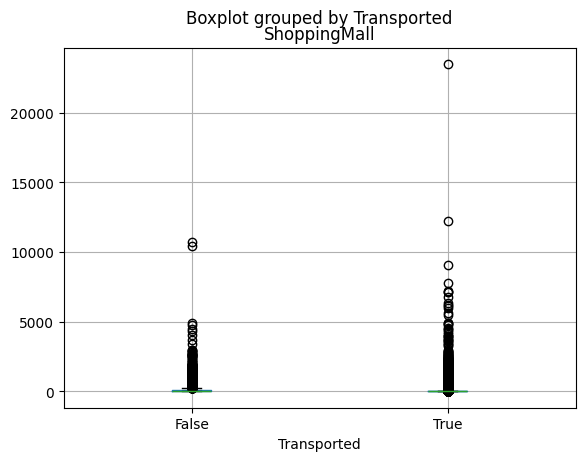

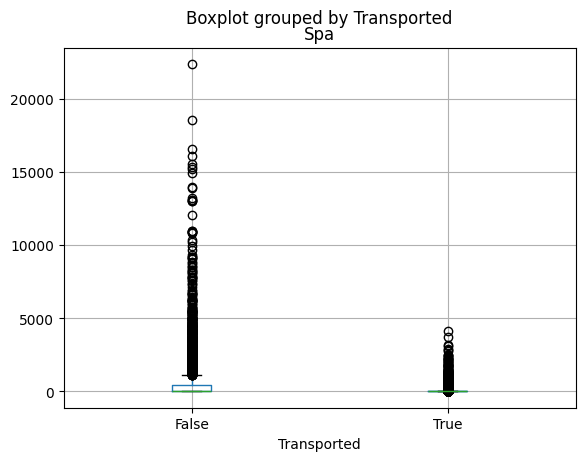

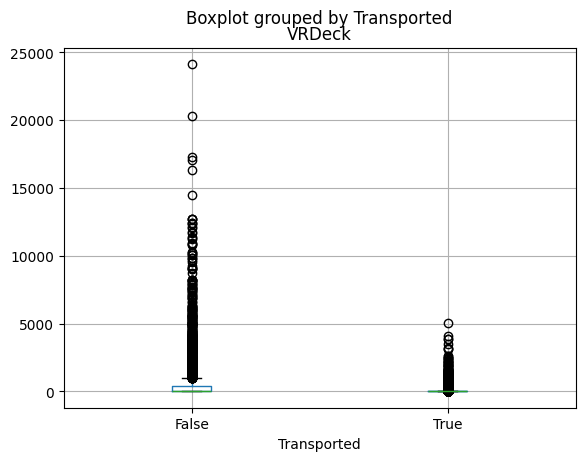

In [ ]:
for col in cat_cols:
    print(pd.crosstab(df_train[col], df_train["Transported"], normalize="index"))

for col in num_cols:
    df_train.boxplot(column=col, by="Transported")
    plt.show()

In [ ]:
# Dividir Cabin en Deck, Num, Side
df_train["Deck"] = df_train["Cabin"].str.split("/").str[0]
df_train["CabinNum"] = df_train["Cabin"].str.split("/").str[1]
df_train["Side"] = df_train["Cabin"].str.split("/").str[2]

print(df_train["Deck"].value_counts(dropna=False))
print(df_train["Side"].value_counts(dropna=False))

# Relación con el target
print(pd.crosstab(df_train["Deck"], df_train["Transported"], normalize="index"))
print(pd.crosstab(df_train["Side"], df_train["Transported"], normalize="index"))

Deck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64
Side
S      4288
P      4206
NaN     199
Name: count, dtype: int64
Transported     False     True 
Deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.319946  0.680054
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.439871
G            0.483783  0.516217
T            0.800000  0.200000
Transported     False     True 
Side                           
P            0.548740  0.451260
S            0.444963  0.555037


In [ ]:
# Dividir Cabin en Deck, Num, Side

df_train["Deck"] = df_train["Cabin"].str.split("/").str[0]

df_train["CabinNum"] = pd.to_numeric(
    df_train["Cabin"].str.split("/").str[1],
    errors="coerce"
)

df_train["Side"] = df_train["Cabin"].str.split("/").str[2]

print(df_train["Deck"].value_counts(dropna=False))
print(df_train["Side"].value_counts(dropna=False))

print(pd.crosstab(
    df_train["Deck"],
    df_train["Transported"],
    normalize="index"
))

print(pd.crosstab(
    df_train["Side"],
    df_train["Transported"],
    normalize="index"
))

Deck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64
Side
S      4288
P      4206
NaN     199
Name: count, dtype: int64
Transported     False     True 
Deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.319946  0.680054
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.439871
G            0.483783  0.516217
T            0.800000  0.200000
Transported     False     True 
Side                           
P            0.548740  0.451260
S            0.444963  0.555037


In [ ]:
# Evaluación de CabinNum antes de decidir si se descarta

print(
    "Cardinalidad de CabinNum:",
    df_train["CabinNum"].nunique(dropna=True)
)

print(
    "Porcentaje de valores únicos:",
    round(
        df_train["CabinNum"].nunique(dropna=True)
        / df_train["CabinNum"].notna().sum()
        * 100,
        2
    ),
    "%"
)

print(df_train["CabinNum"].describe())

Cardinalidad de CabinNum: 1817
Porcentaje de valores únicos: 21.39 %
count    8494.000000
mean      600.367671
std       511.867226
min         0.000000
25%       167.250000
50%       427.000000
75%       999.000000
max      1894.000000
Name: CabinNum, dtype: float64


In [ ]:
# Agrupación de CabinNum por zonas de la nave

bins_cabin = [
    -np.inf,
    299,
    599,
    899,
    1199,
    1499,
    np.inf
]

labels_cabin = [
    "0-299",
    "300-599",
    "600-899",
    "900-1199",
    "1200-1499",
    "1500+"
]

df_train["CabinNumBin"] = pd.cut(
    df_train["CabinNum"],
    bins=bins_cabin,
    labels=labels_cabin
)

print(df_train["CabinNumBin"].value_counts(dropna=False))

print(
    pd.crosstab(
        df_train["CabinNumBin"],
        df_train["Transported"],
        normalize="index"
    )
)

CabinNumBin
0-299        3560
300-599      1488
900-1199      992
600-899       976
1200-1499     938
1500+         540
NaN           199
Name: count, dtype: int64
Transported     False     True 
CabinNumBin                    
0-299        0.461798  0.538202
300-599      0.588038  0.411962
600-899      0.456967  0.543033
900-1199     0.394153  0.605847
1200-1499    0.579957  0.420043
1500+        0.585185  0.414815


### Evaluación de `CabinNum`

Antes de descartar `CabinNum`, se evaluó su cardinalidad y su posible relación con la variable objetivo. El número exacto de cabina presenta una gran cantidad de valores diferentes, por lo que utilizarlo directamente como variable categórica podría generar demasiadas categorías y dificultar el aprendizaje del modelo.

Sin embargo, se evaluó una agrupación por intervalos de número de cabina para conservar información sobre la ubicación aproximada del pasajero dentro de la nave. Por esta razón, se descarta `CabinNum` en su forma original, pero se conserva la variable derivada `CabinNumBin`.


Deck muestra relación clara con el target: B (73.4%) y C (68.0%) tienden a ser transportados, mientras E (35.7%) y F (44.0%) tienden a no serlo. T marca 80%/20% pero solo tiene 5 casos, así que no es confiable. Side también se relaciona, más ligero: S 55.5% vs P 45.1%. Ambas tienen 199 nulos (2.3%), igual que el resto del dataset.

### Clasificación de Valores Faltantes: Informativos vs. Reales

Para decidir la estrategia de imputación en el Paso 4, es indispensable entender el contexto del problema y cómo interactúan las variables entre sí. A partir de la descripción del dataset, podemos clasificar los nulos de la siguiente manera:

*   **Faltantes Informativos (Dependencia Lógica):** Las variables financieras (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) representan los gastos de los pasajeros. Según la lógica del viaje, los pasajeros que están en estado de animación suspendida (`CryoSleep == True`) están confinados a sus cabinas y no pueden consumir servicios. Por lo tanto, cualquier valor nulo en estas columnas para un pasajero dormido no es un dato perdido al azar, sino un **0 lógico**. De igual forma, si un pasajero tiene nulo en `CryoSleep` pero tiene gastos registrados mayores a cero, lógicamente sabemos que `CryoSleep == False`.
* **Faltantes Reales:** Variables como `Age`, `Destination`, `Cabin` y `HomePlanet` presentan nulos que no pueden deducirse mediante una regla lógica directa. Para `Age` y las variables numéricas se utilizarán medidas robustas como la mediana. Para `HomePlanet` se aprovechará primero la información del grupo de viaje: si otro integrante del mismo grupo tiene un planeta conocido y consistente, se utilizará ese valor. Únicamente los casos que no puedan resolverse mediante el grupo se completarán utilizando la moda global.


In [ ]:
# Comprobación de la hipótesis de CryoSleep y Gastos
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

print("Gasto total de pasajeros en CryoSleep = True ")
print(df_train[df_train['CryoSleep'] == True][spend_cols].sum())

print("\nNulos en gastos para pasajeros en CryoSleep = True")
print(df_train[df_train['CryoSleep'] == True][spend_cols].isnull().sum())

print("\n Pasajeros con CryoSleep nulo, pero con gastos > 0")
gastos_totales = df_train[spend_cols].sum(axis=1)
cryo_nulo_con_gasto = df_train[(df_train['CryoSleep'].isnull()) & (gastos_totales > 0)]
print(f"Total de casos inferidos como CryoSleep = False: {cryo_nulo_con_gasto.shape[0]}")

Gasto total de pasajeros en CryoSleep = True 
RoomService     0.0
FoodCourt       0.0
ShoppingMall    0.0
Spa             0.0
VRDeck          0.0
dtype: float64

Nulos en gastos para pasajeros en CryoSleep = True
RoomService     68
FoodCourt       70
ShoppingMall    96
Spa             65
VRDeck          62
dtype: int64

 Pasajeros con CryoSleep nulo, pero con gastos > 0
Total de casos inferidos como CryoSleep = False: 119


**Analisis**

* Gasto total de pasajeros en CryoSleep = True: Los que suman 0 explica que ningún pasajero de este tipo gasto dinero en la nave
* Nulos en gastos CryoSleep = True: Los nulos explica la existencia de faltantes informativos, dado que los dormidos no gastan, podemos remplzara con 0s los nulos
* CryoSleep nulo, pero con gastos > 0: Son 119, y estos se innterpretan como un faltante real, dado que estaba despierto el pasajero y no gasto. Enotnces podemos dejar como False que estaba dormido

In [ ]:
df_train["group"] = df_train["PassengerId"].str.split("_").str[0]
group_sizes = df_train["group"].value_counts()
df_train["group_size"] = df_train["group"].map(group_sizes)
print(pd.crosstab(df_train["group_size"], df_train["Transported"], normalize="index"))

Transported     False     True 
group_size                     
1            0.547555  0.452445
2            0.461950  0.538050
3            0.406863  0.593137
4            0.359223  0.640777
5            0.407547  0.592453
6            0.385057  0.614943
7            0.458874  0.541126
8            0.605769  0.394231


El tamaño de grupo también se relaciona con el target: viajar solo (55% de los pasajeros) se asocia con menor probabilidad de ser transportado (45.2%), mientras que los grupos medianos (3 a 6 personas) muestran las probabilidades más altas (59%-64%). En grupos muy grandes (7-8 personas) la tendencia se revierte, aunque con muestra reducida (solo 13 grupos de tamaño 8), por lo que ese extremo debe tomarse con cautela. Esto sugiere que crear una variable binaria como TraveledAlone podría capturar señal útil para el modelo.

## Analisis Especifico de Variables

**Revision Passenger**

Es importante mencionar que el formato de `PassengerId` es `gggg_pp`,
donde `gggg` es un identificador de grupo de 4 dígitos y `pp` es el número
de pasajero dentro de ese grupo (dos dígitos). Esta información proviene
del diccionario de datos de la competencia de Kaggle.

En este contexto, un grupo no necesariamente significa una familia, aunque
la mayoría de estos sí lo son. Esto es relevante porque nos permite explorar
si viajar en grupo (y no solo el vínculo familiar en sí) tiene alguna relación
con la probabilidad de haber sido transportado — por ejemplo, si los
integrantes de un mismo grupo tienden a compartir el mismo resultado en
`Transported`.

In [ ]:
#Extraer el grpo de passengerid
df_train["group"] = df_train["PassengerId"].str.split("_").str[0]
print(df_train["group"])

0       0001
1       0002
2       0003
3       0003
4       0004
        ... 
8688    9276
8689    9278
8690    9279
8691    9280
8692    9280
Name: group, Length: 8693, dtype: object


Extraemos el identificador de grupo (`gggg`) de cada pasajero a partir de
`PassengerId`, dividiendo el valor por el separador `_` y quedándonos con
la primera parte. Los valores resultantes (0001, 0002, 0003...) corresponden
al grupo, no al número de pasajero dentro del grupo (`pp`).

In [ ]:
group_sizes = df_train["group"].value_counts()
print(group_sizes)

group
9081    8
4005    8
8988    8
5133    8
4256    8
       ..
0022    1
0016    1
0015    1
0014    1
0012    1
Name: count, Length: 6217, dtype: int64


In [ ]:
group_size_counts = group_sizes.value_counts().sort_index()
print(group_size_counts)

count
1    4805
2     841
3     340
4     103
5      53
6      29
7      33
8      13
Name: count, dtype: int64


Podemos observar que lso grupos más grandes son de 8 personas mientras que el mas pequeño es de solamente una. Con un total de 6217 grupos distintos entre los 8693 pasajeros totales.

También podemos observar que 4805 de esos grupos tienen un tamaño de 1, lo que siginifica que aproximadamnet el 55% de los pasajeros viajan sin acompáñante. El resto se distribuye en grupos cada vez más pequeños conforme aumenta el tamaño, desde 841 grupos de 2 personas hasta 13 grupos de 8 personas.  

**Revisión de HomePlanet**

In [ ]:
df_train["HomePlanet"].unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

Home planet nos indica el planeta desde donde partió el pasajero, en este caso Europa, Earth y Mars. Podemos ver que hay valores nulos en esta columna

In [ ]:
df_train["HomePlanet"].value_counts()

,count
HomePlanet,
Earth,4602
Europa,2131
Mars,1759


In [ ]:
df_train["HomePlanet"].isnull().sum()

np.int64(201)

In [ ]:
df_train["HomePlanet"].value_counts(normalize=True, dropna=False) * 100

,proportion
HomePlanet,
Earth,52.939146
Europa,24.513977
Mars,20.234672
NaN,2.312205


Podemos obseravr que al rededor del 53% de pasajeros vienen de la tierra, el 25% vienen de Europa, el 20% viene de Marte y el resto son valores nulos lo que quiere decir que es información que se perdió en el incidente

# 3. Selección y descarte de variables

**Variables a mantener:**

* `HomePlanet`, `CryoSleep`, `Destination`, `Age` y las variables de gasto continuo se conservan debido a la información observada durante el EDA.
* `Deck`, `Side` y `group_size` se conservan debido a que durante el EDA mostraron relación con la variable objetivo.
* `HasSpent` se conserva porque representa de forma binaria el patrón de gasto cero frente a gasto positivo identificado durante el EDA.
* `CabinNumBin` se conserva porque permite capturar información de la posición aproximada de la cabina sin utilizar directamente la alta cardinalidad de `CabinNum`.


**Variables a descartar:**

* `Name` y `PassengerId` se descartan porque funcionan principalmente como identificadores. Antes de eliminar `PassengerId`, se utilizó para obtener las variables `group` y `group_size`.
* `Cabin` se descarta después de extraer de ella las variables `Deck`, `Side` y `CabinNum`.
* `CabinNum` se descarta en su forma original después de evaluar su cardinalidad y su relación con el target mediante agrupaciones. En su lugar, se conserva `CabinNumBin`, que reduce la cardinalidad y preserva parte de la información espacial.
* `VIP` se descarta después de evaluar su distribución y su relación con `Transported`, considerando su fuerte desbalance.


In [ ]:
print("Distribución de VIP (%):")

print(
    df_train["VIP"]
    .value_counts(
        normalize=True,
        dropna=False
    ) * 100
)


print("\nRelación VIP vs Transported:")

print(
    pd.crosstab(
        df_train["VIP"],
        df_train["Transported"],
        normalize="index"
    )
)

Distribución de VIP (%):
VIP
False    95.375590
NaN       2.335212
True      2.289198
Name: proportion, dtype: float64

Relación VIP vs Transported:
Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910


In [ ]:
cols_to_drop = ['PassengerId', 'Name', 'Cabin', 'CabinNum', 'VIP']

df_train_selected = df_train.drop(columns=cols_to_drop)

print(df_train.shape)
print(df_train_selected.shape)
print(df_train_selected.columns.tolist())

(8693, 26)
(8693, 21)
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'Has_RoomService', 'Has_FoodCourt', 'Has_ShoppingMall', 'Has_Spa', 'Has_VRDeck', 'HasSpent', 'Deck', 'Side', 'CabinNumBin', 'group', 'group_size']


# 4. Manejo de faltantes

A partir de la clasificación realizada en el Análisis Exploratorio, aplicaremos una estrategia de imputación mixta, lógica y estadística. Cada decisión se justifica de la siguiente manera:

*   **Imputación Lógica:**
    *   **`CryoSleep`:** Como demostramos previamente, si un pasajero registra gastos totales mayores a 0, inferimos con certeza que no está en animación suspendida. Se imputarán con `False`.
    *   **Variables Financieras (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`):** Si un pasajero está en `CryoSleep == True`, lógicamente no pudo consumir servicios. Estos faltantes informativos se imputarán con `0.0`.
*   **Imputación Estadística (Faltantes Reales):**
    *   **Numéricas (Gastos restantes y `Age`):** Se imputarán utilizando la **mediana**. Para las variables de gasto, la media sería un error debido a la presencia masiva de outliers detectados por la regla de Tukey y al sesgo positivo extremo, 0skewness > 6. Para `Age`, la mediana también otorga robustez frente a pasajeros de edad atípica.
    *   **Categóricas (`HomePlanet`, `Destination`, `Deck`, `Side`, y el resto de `CryoSleep`):** Al ser variables cualitativas, se imputarán utilizando la **moda** (el valor más frecuente de la distribución).

In [ ]:
df_clean = df_train_selected.copy()
spend_cals = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"]

### imputaciones logicas


In [ ]:
gastos_totales = df_clean[spend_cols].sum(axis=1)

# si tiene gastos > 0, lógicamente CryoSleep es False
df_clean.loc[(df_clean['CryoSleep'].isnull()) & (gastos_totales > 0), 'CryoSleep'] = False

# si CryoSleep es True, los gastos lógicamente son 0.0
for col in spend_cols:
    df_clean.loc[(df_clean['CryoSleep'] == True) & (df_clean[col].isnull()), col] = 0.0

In [ ]:
# Imputación relacional de HomePlanet usando el grupo del pasajero

def planeta_consistente(serie):
    valores = serie.dropna().unique()

    if len(valores) == 1:
        return valores[0]

    return np.nan


homeplanet_por_grupo = (
    df_clean
    .groupby("group")["HomePlanet"]
    .agg(planeta_consistente)
)

mask_hp = df_clean["HomePlanet"].isnull()

df_clean.loc[
    mask_hp,
    "HomePlanet"
] = df_clean.loc[
    mask_hp,
    "group"
].map(homeplanet_por_grupo)


print(
    "HomePlanet faltantes después de inferencia por grupo:",
    df_clean["HomePlanet"].isnull().sum()
)

HomePlanet faltantes después de inferencia por grupo: 111


### imputaciones estadisticas

In [ ]:
# numericas con mediana
num_cols_to_impute = ['Age'] + spend_cols
for col in num_cols_to_impute:
  mediana = df_clean[col].median()
  df_clean[col] = df_clean[col].fillna(mediana)

# categoricas con moda
cat_cols_to_impute = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'Deck',
    'Side'
    'CabinNumBin'
    'HasSpent'
    ]
for col in cat_cols_to_impute:
  moda = df_clean[col].mode()[0]
  df_clean[col] = df_clean[col].fillna(moda)

print("nulos restantes: ", df_clean.isnull().sum())


nulos restantes:  HomePlanet            0
CryoSleep             0
Destination           0
Age                   0
RoomService           0
FoodCourt             0
ShoppingMall          0
Spa                   0
VRDeck                0
Transported           0
Has_RoomService     181
Has_FoodCourt       183
Has_ShoppingMall    208
Has_Spa             183
Has_VRDeck          188
HasSpent              0
Deck                  0
Side                  0
CabinNumBin         199
group                 0
group_size            0
dtype: int64


/tmp/ipykernel_1568/2674098861.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean[col] = df_clean[col].fillna(moda)


# 5. Codificación de variables categóricas

Para codificar las variables categóricas, seleccionamos la estrategia basándonos en la naturaleza de cada característica para no introducir sesgos algorítmicos:

*   **Variables Binarias (`CryoSleep`, `Side`, `Transported`):** Al tener solo dos estados posibles, aplicaremos una codificación binaria directa. Para `Side`, asignaremos arbitrariamente $0$ a babor ('P') y $1$ a estribor ('S'). Convertiremos los booleanos de `CryoSleep` y el target `Transported` a enteros. Usar One-Hot Encoding aquí solo generaría columnas perfectamente colineales y redundantes.
*   **Variables Nominales (`HomePlanet`, `Destination`, `Deck`):** No existe un orden matemático intrínseco entre los planetas o los destinos. Para `Deck` (las cubiertas), aunque físicamente tienen un orden espacial, la relación con el target no es lineal, por lo que tratarla como ordinal podría confundir al modelo. Por esto, aplicaremos **One-Hot Encoding (OHE)** creando variables dummy. Utilizaremos el parámetro `drop_first=True` para evitar la trampa de las variables ficticias (multicolinealidad perfecta).
*   **Limpieza final:** Eliminaremos la columna `group`, ya que fue una variable temporal (string) creada para derivar `group_size`. Su altísima cardinalidad (6217 grupos) arruinaría la dimensionalidad del modelo si se intenta codificar.

In [ ]:
df_encoded = df_clean.copy()
if 'group' in df_encoded.columns:
    df_encoded = df_encoded.drop(columns=['group'])

# Binaria Directa
df_encoded['CryoSleep'] = df_encoded['CryoSleep'].astype(int)
df_encoded['Transported'] = df_encoded['Transported'].astype(int)
df_encoded['Side'] = df_encoded['Side'].map({'P': 0, 'S': 1})

# One-Hot Encoding para Nominales
cols_to_ohe = ['HomePlanet', 'Destination', 'Deck', 'CabinNumBin','HasSpent']
df_encoded = pd.get_dummies(df_encoded, columns=cols_to_ohe, drop_first=True, dtype=int)

print("Tipos de datos después de la codificación:")
print(df_encoded.dtypes)

Tipos de datos después de la codificación:
CryoSleep                       int64
Age                           float64
RoomService                   float64
FoodCourt                     float64
ShoppingMall                  float64
Spa                           float64
VRDeck                        float64
Transported                     int64
Has_RoomService               float64
Has_FoodCourt                 float64
Has_ShoppingMall              float64
Has_Spa                       float64
Has_VRDeck                    float64
HasSpent                      float64
Side                            int64
CabinNumBin                  category
group_size                      int64
HomePlanet_Europa               int64
HomePlanet_Mars                 int64
Destination_PSO J318.5-22       int64
Destination_TRAPPIST-1e         int64
Deck_B                          int64
Deck_C                          int64
Deck_D                          int64
Deck_E                          int64
Deck_F 

In [ ]:
objetos_restantes = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas de tipo 'object' restantes: {len(objetos_restantes)}")
if len(objetos_restantes) > 0:
    print(objetos_restantes)

Columnas de tipo 'object' restantes: 0


# 6. Transformación de variables numéricas

Basándonos en los resultados del Análisis Exploratorio Paso 2, observamos que las variables de gasto financiero presentan un sesgo positivo extremo, con valores de skewness entre 6.3 y 12.6. Por el contrario, la variable `Age` tiene un sesgo de 0.42, lo cual indica una distribución casi simétrica que no requiere ajuste.

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1568/1650712612.py:18: SyntaxWarning: invalid escape sequence '\l'
  axes[i, 1].set_title(f"Después: $\log(x+1)$ {col}\n(Skewness: {df_trans[col].skew():.2f})")


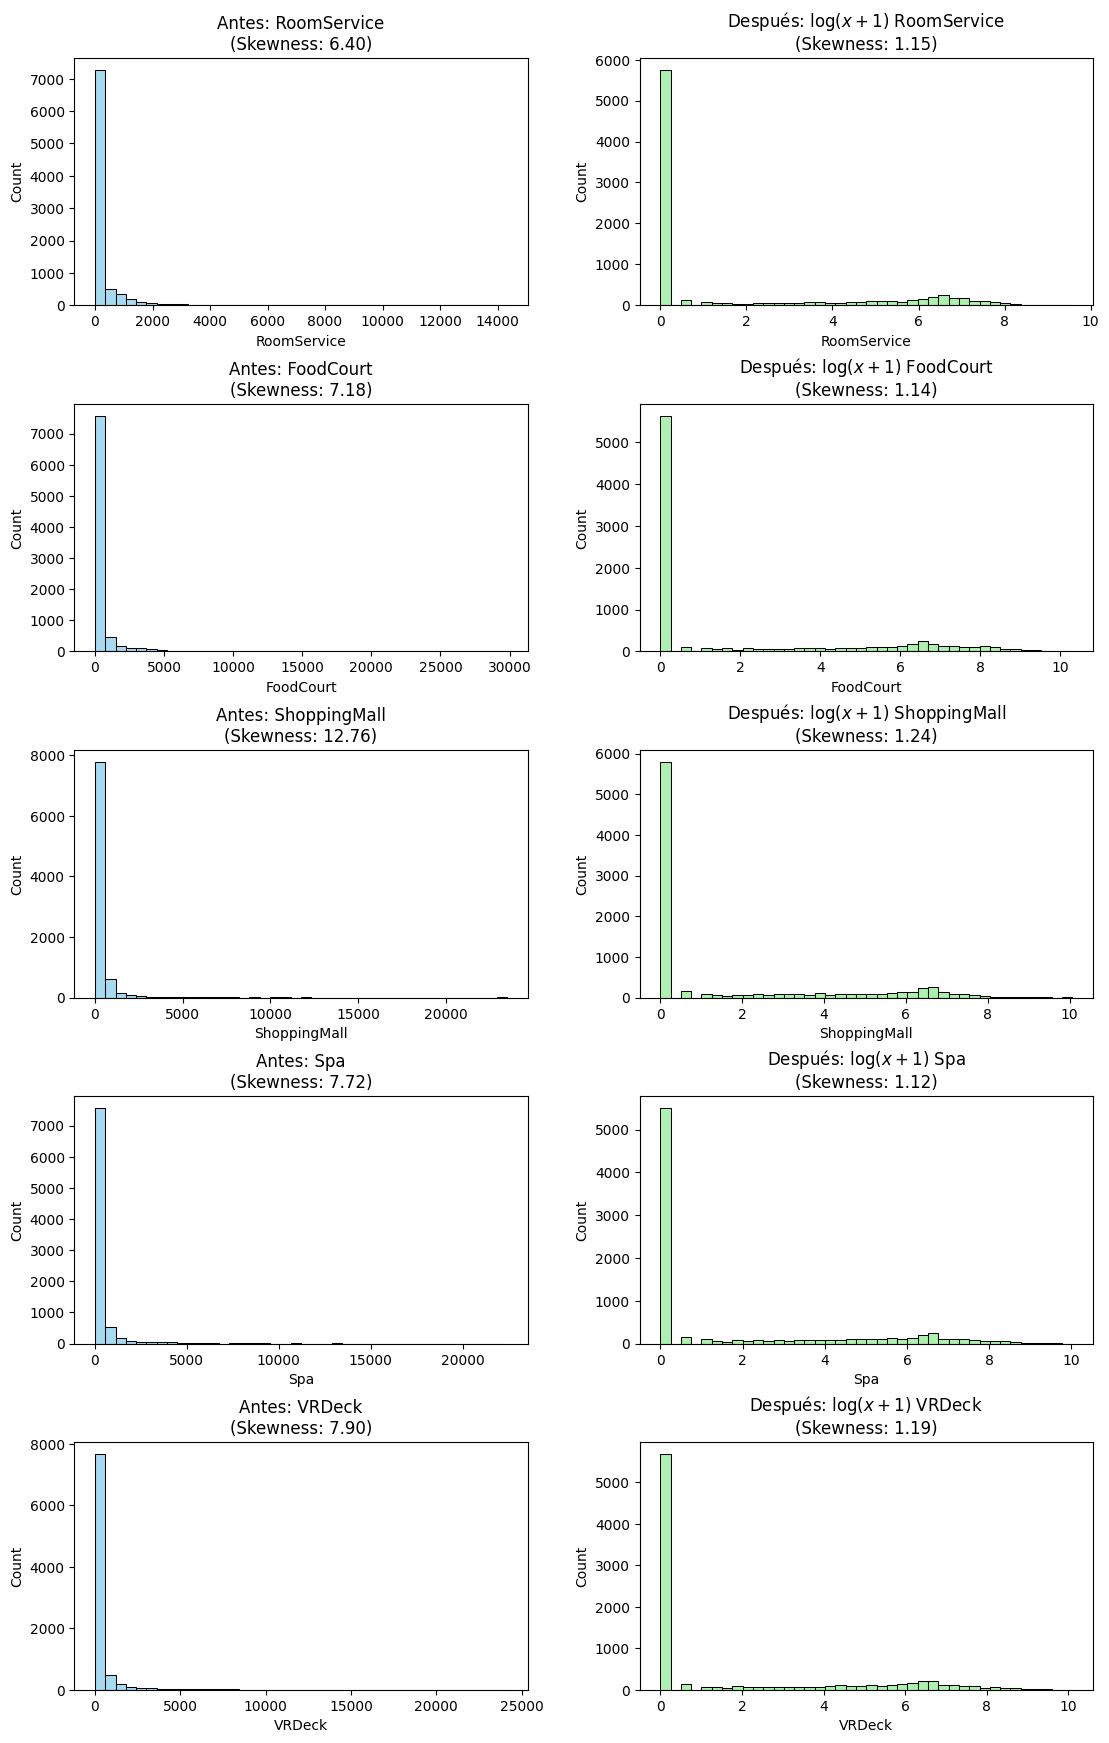

In [ ]:
df_trans = df_encoded.copy()

spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
fig.tight_layout(pad=5.0)

for i, col in enumerate(spend_cols):
    # gráfico Antes de la transformación
    sns.histplot(df_clean[col], bins=40, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f"Antes: {col}\n(Skewness: {df_clean[col].skew():.2f})")

    # aplicamos la transformación log(x+1)
    df_trans[col] = np.log1p(df_trans[col])

    # gráfico Después de la transformación
    sns.histplot(df_trans[col], bins=40, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f"Después: $\log(x+1)$ {col}\n(Skewness: {df_trans[col].skew():.2f})")

plt.show()

Para estabilizar la varianza y reducir el impacto de la pesada cola derecha en las variables de gasto, aplicaremos una transformación logarítmica. Dado que existen múltiples valores iguales a cero (pasajeros que no gastaron), utilizaremos la función $\log(x+1)$ para evitar indeterminaciones matemáticas al calcular el logaritmo de cero.

Como se pbserva en los graficos, lgramos comprimir la cola de los valores atipicos, reduciendo skewness a valores mas manejables para el algoritmo

In [ ]:
print(f"Skewness de Age sin transformar: {df_trans['Age'].skew():.2f}")

Skewness de Age sin transformar: 0.43


# 7. ESCALADO DE VARIABLES

**Justificación de la elección del escalador:**
Durante el Análisis Exploratorio, Paso 2, detectamos mediante la regla de Tukey la presencia de outliers en la variable `Age` (77 valores atípicos) y una cantidad masiva de outliers en las variables financieras (alrededor de 1,800 casos por cada una). Aunque aplicamos una transformación logarítmica en el Paso 6 para suavizar la asimetría de los gastos, las distribuciones siguen sin ser perfectamente normales y los valores extremos relativos aún existen.

In [ ]:
num_cols_to_scale = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'group_size']

print("Estadísticas de las variables numéricas antes de escalado:")
df_trans[num_cols_to_scale].describe().round(3)

Estadísticas de las variables numéricas antes de escalado:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group_size
count,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000
mean,28.790,1.735,1.907,1.599,1.839,1.758,2.036
std,14.341,2.719,2.933,2.567,2.769,2.747,1.596
min,0.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,20.000,0.000,0.000,0.000,0.000,0.000,1.000
50%,27.000,0.000,0.000,0.000,0.000,0.000,1.000
75%,37.000,3.738,4.127,3.135,3.989,3.714,3.000
max,79.000,9.570,10.303,10.064,10.017,10.091,8.000


In [ ]:
from sklearn.preprocessing import RobustScaler

df_scaled = df_trans.copy()
scaler = RobustScaler()

df_scaled[num_cols_to_scale] = scaler.fit_transform(df_scaled[num_cols_to_scale])
print(df_scaled)

      CryoSleep       Age  RoomService  FoodCourt  ShoppingMall       Spa  \
0             0  0.705882     0.000000   0.000000      0.000000  0.000000   
1             0 -0.176471     1.257597   0.557914      1.039101  1.581836   
2             0  1.823529     1.012446   1.982557      0.000000  2.209146   
3             0  0.352941     0.000000   1.734311      1.887707  2.033282   
4             0 -0.647059     1.529570   1.032843      1.602261  1.589025   
...         ...       ...          ...        ...           ...       ...   
8688          0  0.823529     0.000000   2.138921      0.000000  1.856334   
8689          1 -0.529412     0.000000   0.000000      0.000000  0.000000   
8690          0 -0.058824     0.000000   0.000000      2.403225  0.173765   
8691          0  0.294118     0.000000   1.685563      0.000000  1.471376   
8692          0  1.000000     1.296045   2.048146      0.000000  0.000000   

        VRDeck  Transported  Has_RoomService  Has_FoodCourt  ...  \
0     0

Elegimos **`RobustScaler`**. Este escalador sustrae la mediana y divide por el rango intercuartílico (IQR). Al utilizar estadísticas robustas, asegura que los valores atípicos no dominen la escala de nuestras variables numéricas.

In [ ]:
print("Estadísticas de las variables numéricas tras aplicar RobustScaler:")
df_scaled[num_cols_to_scale].describe().round(3)

Estadísticas de las variables numéricas tras aplicar RobustScaler:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,group_size
count,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000,8693.000
mean,0.105,0.464,0.462,0.510,0.461,0.473,0.518
std,0.844,0.728,0.711,0.819,0.694,0.740,0.798
min,-1.588,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.412,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.588,1.000,1.000,1.000,1.000,1.000,1.000
max,3.059,2.560,2.496,3.210,2.511,2.717,3.500


Comparando el output de codigo `.describe() `entre df_scaled y df_trans, notamos que las estadisticas mejorn al aplicar scaled. Ahora las std std son mas normales entre cada dato y esto hace que en la aplicación del modelo no se sesgue el modelo por los pesos inherentes de cada variable

# Verificacion final y conclusiones

## 1. Confirmar que no quedan nulos

In [ ]:
total_nulos = df_scaled.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {total_nulos}")


Total de valores nulos en el dataset: 1142


## 2. Confirmar que no quedan columnas tipo object

In [ ]:
objetos_restantes = df_scaled.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas de tipo 'object' restantes: {len(objetos_restantes)}")

Columnas de tipo 'object' restantes: 0


## 3. Reportar el shape final


In [ ]:
print(f"Shape final del dataset procesado: {df_scaled.shape}")
print(f"   -> {df_scaled.shape[0]} filas (pasajeros)")
print(f"   -> {df_scaled.shape[1]} columnas (características procesadas)")

Shape final del dataset procesado: (8693, 28)
   -> 8693 filas (pasajeros)
   -> 28 columnas (características procesadas)


In [ ]:
display(df_scaled.head())

,CryoSleep,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Has_RoomService,Has_FoodCourt,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0,0.705882,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.0,0.0,...,0,0,1,1,0,0,0,0,0,0
1,0,-0.176471,1.257597,0.557914,1.039101,1.581836,1.025068,1,1.0,1.0,...,0,0,1,0,0,0,0,1,0,0
2,0,1.823529,1.012446,1.982557,0.000000,2.209146,1.053439,0,1.0,1.0,...,0,0,1,0,0,0,0,0,0,0
3,0,0.352941,0.000000,1.734311,1.887707,2.033282,1.418542,0,0.0,1.0,...,0,0,1,0,0,0,0,0,0,0
4,0,-0.647059,1.529570,1.032843,1.602261,1.589025,0.295837,1,1.0,1.0,...,0,0,1,0,0,0,0,1,0,0


## Tabla Resumen de Decisiones

| Variable | Tipo Inicial | Tratamiento Aplicado | Justificación |
| :--- | :--- | :--- | :--- |
| **PassengerId** | Object | Extracción y Descarte | Se extrajo el grupo (`group_size`). Como ID único no aporta valor predictivo. |
| **HomePlanet** | Object | Imputación (Moda) + OHE | Faltante real. Categórica nominal sin orden matemático intrínseco. |
| **CryoSleep** | Object | Imputación Lógica/Moda + Binaria (0/1) | Nulos deducibles (si gasto > 0, es `False`). Al ser dicotómica, se binariza directamente. |
| **Cabin** | Object | Extracción y Descarte | Alta cardinalidad. Se separó en `Deck`, `CabinNum` y `Side`. |
| **Destination** | Object | Imputación (Moda) + OHE | Faltante real. Categórica nominal, requiere variables dummy. |
| **Age** | Float | Imputación (Mediana) + RobustScaler | Faltante real. Distribución simétrica pero con presencia de outliers detectados por Tukey. |
| **VIP** | Object | Descarte | Desbalance masivo (95.4% no VIP) sin contraste suficiente respecto a la variable objetivo. |
| **Variables de Gasto** | Float | Imputación Lógica/Mediana + $\log(x+1)$ + RobustScaler | Si `CryoSleep == True`, el gasto es 0. Fuerte sesgo positivo (>6) corregido con logaritmo y escalado tolerante a outliers masivos. |
| **Name** | Object | Descarte | Alta cardinalidad. Identificador sin valor predictivo directo. |
| **Deck** (Extraída) | Object | Imputación (Moda) + OHE | Faltante real. Fuerte relación con el target (B y C tienen mayor tasa de transporte). |
| **CabinNum** (Extraída)| Object | Descarte | Cardinalidad extrema, fungiría como ruido sin agrupación previa. |
| **Side** (Extraída) | Object | Imputación (Moda) + Binaria (0/1) | Faltante real. Ligeras diferencias en supervivencia. Al ser dicotómica, se mapea a 0 y 1. |
| **group_size** (Extraída)| Numérica | RobustScaler | Continua/Discreta. Muestra relación con el target (grupos medianos sobreviven más que los solitarios). |
| **Transported** (Target)| Bool | Binarización (0/1) | Variable objetivo. Se codifica para el algoritmo de clasificación. |

---

## Conclusión

El análisis exhaustivo del conjunto de datos de *Spaceship Titanic* reveló patrones estructurales y de comportamiento cruciales para la predicción de la anomalía espacio-temporal:

1. **La regla absoluta del CryoSleep:** La condición de animación suspendida explica el comportamiento financiero del pasajero. Esta interacción determinística permitió recuperar 119 registros perdidos y reconstruir los gastos nulos con un 100% de precisión lógica.
2. **Impacto Espacial (Deck y Side):** La ubicación física del pasajero dentro de la nave es altamente predictiva. Las cubiertas B y C mostraron tasas de transporte superiores al 68%, en contraste con las cubiertas E y F.
3. **Efecto de Grupo:** Viajar solo (55% de la tripulación) reduce las probabilidades de ser transportado frente a viajar en grupos medianos (3 a 6 personas), validando la importancia de la extracción de características desde los IDs.
4. **Distribuciones Atípicas:** La mayoría de los pasajeros presenta gastos nulos o muy bajos, con una minoría generando un sesgo estadístico masivo. El tratamiento dual, logaritmo + escalado robusto, fue vital para preservar la señal sin que los outliers dominen la convergencia del modelo.